# Introduction

This is an analysis of the US federal debt.

**Motivation**: I was frustrated with various news site showing graphs without really showing their sources. I wish more news outlets would provide the source code and actual datasets used to plot graphs.

We show you the code to:
* Fetch the data
* Compute aggregation
* Display results

This way, you can verify and reproduce the results.

### Auction results

The US Treasury creates debt by selling bonds/notes/bills at auctions.

You can see the results of such auctions here: https://treasurydirect.gov/auctions/announcements-data-results/announcement-results-press-releases/auction-results

### Example

When clicking on the "competitive results PDF" column of a bond, we see something like this:

<nop/><div style="width: 500px;">
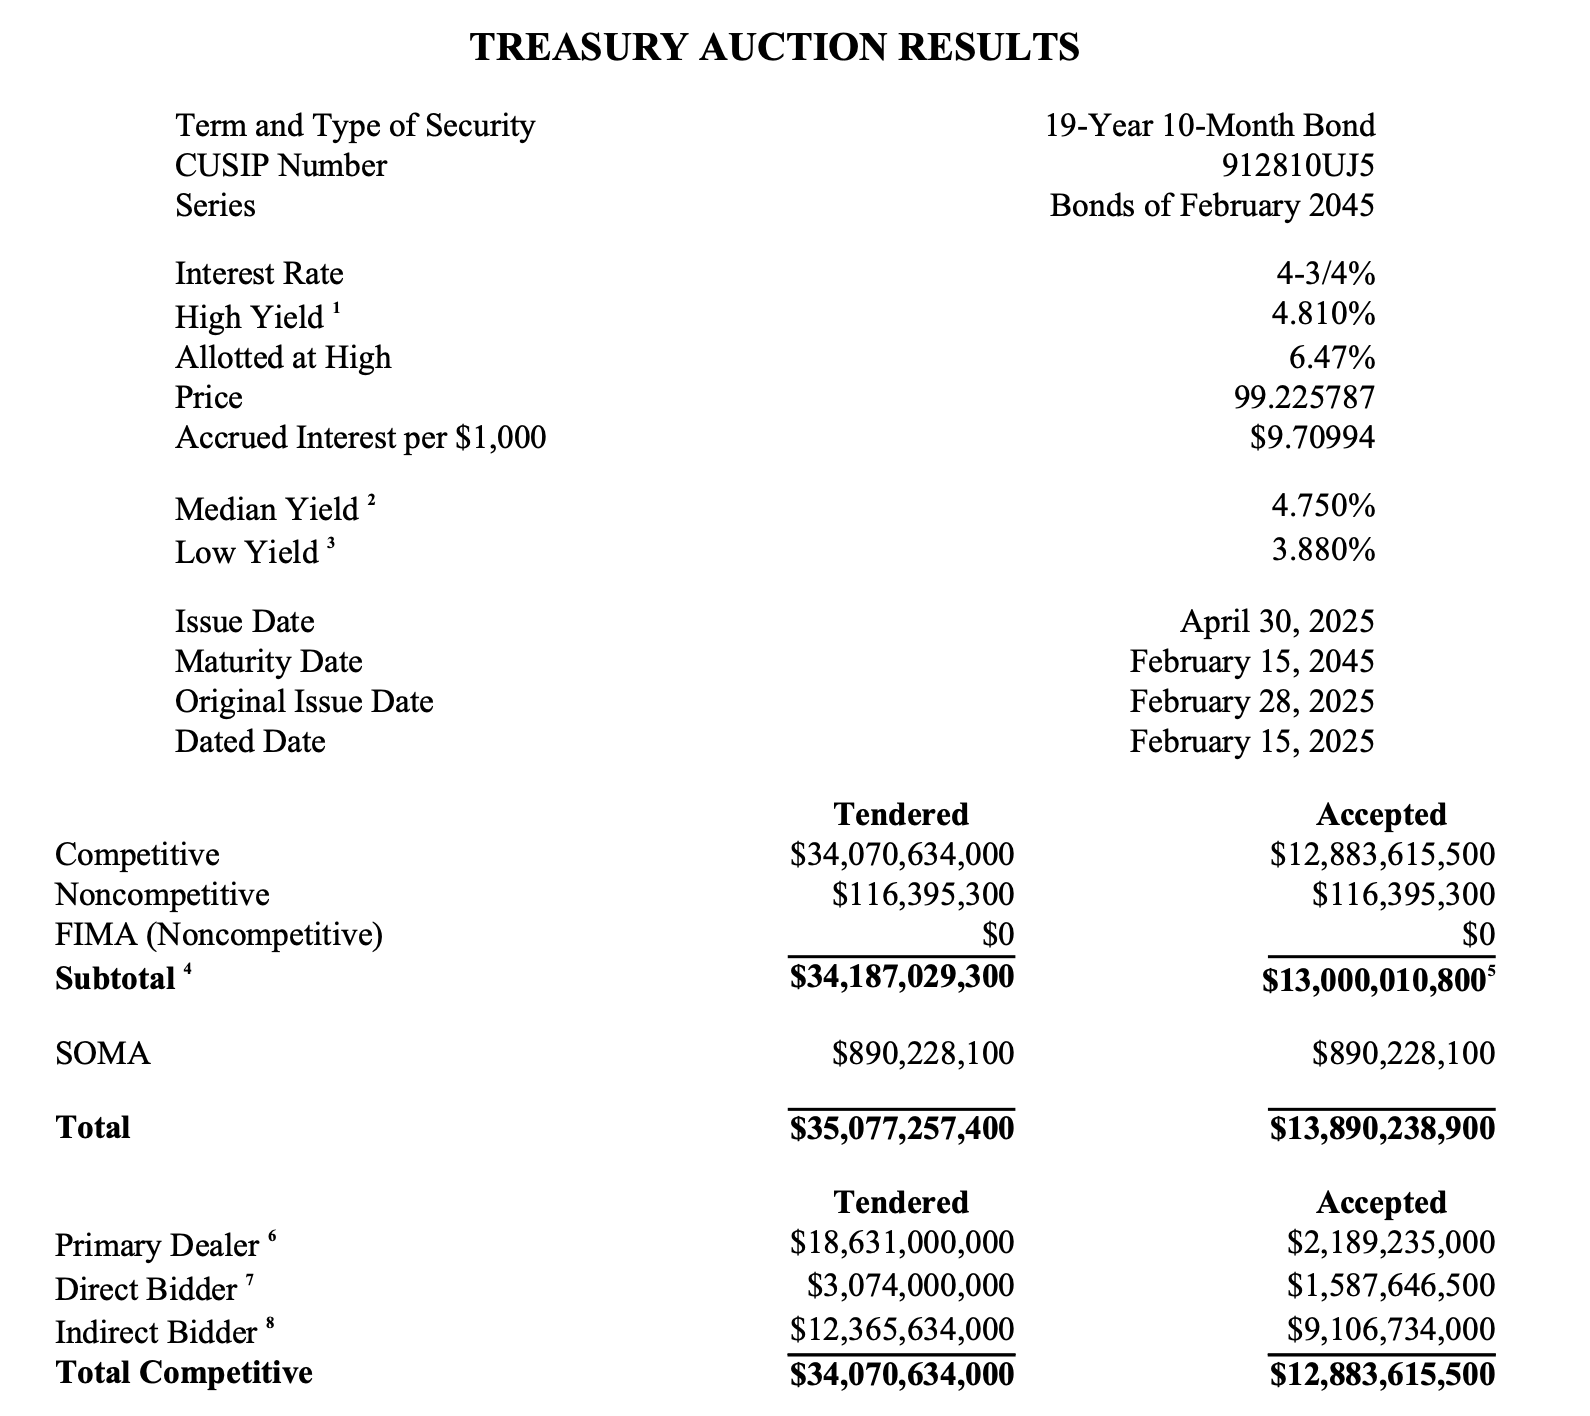
</div>

https://treasurydirect.gov/instit/annceresult/press/preanre/2025/R_20250416_2.pdf

We see a few bits of information:
* The _term_: 19-Year 10-Month. This is because is the same batch of bonds that are being sold 2 months later than the original introduction. This is an important distinction because of the way we classify bonds by term.
* _Issue Date_: The effective date the money is loaned.
* _Maturity Date_: The date when the money is given back. We'll compute the difference with the _Issue date_ to as the effective term duration.
* The _interest rate_: 4.75%
* The _price_ of a \\$100 bond is set \\$99.22 determined by the auction participants. Note that the bonds are sold in a [Dutch auction process](https://www.investopedia.com/terms/d/dutchauction.asp).
* In the _Accepted_ column, the _Total_ is the amount of bonds sold. This is what really matters for us.
* The _Tendered_ column represents all the bids, we don't really care about this. You can see that _Noncompetitive_ and _SOMA_ line items do not participate in the auction (Tendered == Accepted).
* SOMA is the Fed buying bonds to "print money" in order to regulate inflation.

# Fetching the data

Good news, the auctions results are available directly at https://fiscaldata.treasury.gov/datasets/treasury-securities-auctions-data/treasury-securities-auctions-data

Run `python download.py` to fetch the ~11,000 auction results since 1980 into the `data/` folder. The script downloads incrementally (one file per year), so it's safe to run daily to pull the latest data. The cell below loads those files.

In [6]:
# % pip install pandas

ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import math
import re
import os.path
from datetime import datetime, timedelta

import urllib
import json
import xml.etree.ElementTree as ET

from matplotlib import pyplot as plt
import matplotlib.dates as md

import truststore, urllib.request
truststore.inject_into_ssl()

%config InlineBackend.figure_format = 'retina'
pd.options.mode.copy_on_write = True
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

/var/folders/bj/jb1jcwrs1nb3t7v3svf3h_lc0000gn/T/ipykernel_11249/1409704513.py:19: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


In [3]:
def load_data():
    # Data is downloaded by download.py into data/auctions_YYYY.json.
    # Run `python download.py` to fetch/refresh the data.
    import glob

    paths = sorted(glob.glob(os.path.join('data', 'auctions_*.json')))
    if not paths:
        raise FileNotFoundError("No data found in data/. Run `python download.py` first.")

    data = []
    for path in paths:
        with open(path) as f:
            data += json.load(f)
    return data

data = load_data()

In [4]:
data = json.loads(json.dumps(data).replace('"null"', "null"))

In [5]:
df = pd.DataFrame(data)
df['record_date'] = pd.to_datetime(df['record_date'])
df['auction_date'] = pd.to_datetime(df['auction_date'])
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['maturity_date'] = pd.to_datetime(df['maturity_date'])
df['int_rate'] = pd.to_numeric(df['int_rate'])
df['total_accepted'] = pd.array(df['total_accepted'], dtype=pd.Int64Dtype())
df['soma_accepted'] = pd.array(df['soma_accepted'], dtype=pd.Int64Dtype())
df['term'] = df['maturity_date'] - df['issue_date']
df

,record_date,cusip,security_type,security_term,auction_date,issue_date,maturity_date,price_per100,accrued_int_per100,accrued_int_per1000,adj_accrued_int_per1000,adj_price,allocation_pctage,allocation_pctage_decimals,announcemtd_cusip,announcemt_date,auction_format,avg_med_discnt_rate,avg_med_investment_rate,avg_med_price,avg_med_discnt_margin,avg_med_yield,back_dated,back_dated_date,bid_to_cover_ratio,callable,call_date,called_date,cash_management_bill_cmb,closing_time_comp,closing_time_noncomp,comp_accepted,comp_bid_decimals,comp_tendered,comp_tenders_accepted,corpus_cusip,cpi_base_reference_period,currently_outstanding,dated_date,direct_bidder_accepted,direct_bidder_tendered,est_pub_held_mat_by_type_amt,fima_included,fima_noncomp_accepted,fima_noncomp_tendered,first_int_period,first_int_payment_date,floating_rate,frn_index_determination_date,frn_index_determination_rate,...,low_yield,mat_date,max_comp_award,max_noncomp_award,max_single_bid,min_bid_amt,min_strip_amt,min_to_issue,multiples_to_bid,multiples_to_issue,nlp_exclusion_amt,nlp_reporting_threshold,noncomp_accepted,noncomp_tenders_accepted,offering_amt,original_cusip,original_dated_date,original_issue_date,original_security_term,pdf_filenm_announcemt,pdf_filenm_comp_results,pdf_filenm_noncomp_results,primary_dealer_accepted,primary_dealer_tendered,ref_cpi_on_dated_date,ref_cpi_on_issue_date,reopening,security_term_day_month,security_term_week_year,series,soma_accepted,soma_holdings,soma_included,soma_tendered,spread,std_int_payment_per1000,strippable,tiin_conversion_factor_per1000,total_accepted,total_tendered,treas_retail_accepted,treas_retail_tenders_accepted,unadj_accrued_int_per1000,unadj_price,xml_filenm_announcemt,xml_filenm_comp_results,inflation_index_security,tint_cusip_1,tint_cusip_2,term
0,1979-11-15,912827KC5,Note,10-Year,1979-10-31,1979-11-15,1989-11-15,NaN,NaN,0.0000000000,NaN,NaN,99.000000,0,NaN,1979-10-24,Multi-Price,NaN,NaN,100.0,NaN,10.750000,No,NaN,NaN,No,NaN,NaN,No,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,1979-11-15,NaN,NaN,NaN,NaN,NaN,NaN,Normal,1980-05-15,No,NaN,NaN,...,10.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000000000,NaN,NaN,NaN,10-Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,0-Month,10-Year,B-1989,<NA>,NaN,NaN,NaN,NaN,53.7500,NaN,NaN,2401000000,3818000000,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,3653 days
1,1979-11-15,912810CK2,Bond,30-Year,1979-11-01,1979-11-15,2009-11-15,NaN,NaN,0.0000000000,NaN,NaN,44.000000,0,NaN,1979-10-24,Multi-Price,NaN,NaN,99.407,NaN,10.440000,No,NaN,NaN,Yes,2004-11-15,NaN,No,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,1979-11-15,NaN,NaN,NaN,NaN,NaN,NaN,Normal,1980-05-15,No,NaN,NaN,...,10.390000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000000000,NaN,NaN,NaN,30-Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,0-Month,30-Year,Bonds of 2004-2009,<NA>,NaN,NaN,NaN,NaN,51.8750,NaN,NaN,2315000000,3594000000,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,10958 days
2,1980-01-03,9127933Y0,Bill,13-Week,1979-12-28,1980-01-03,1980-04-03,NaN,NaN,NaN,NaN,NaN,21.000000,0,NaN,1979-12-21,Price-Based,12.105000,12.700000,96.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3200000000,NaN,NaN,1979-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,91-Day,13-Week,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3257440000,5371540000,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,91 days
3,1980-01-03,9127934U7,Bill,26-Week,1979-12-28,1980-01-03,1980-07-03,NaN,NaN,NaN,NaN,NaN,94.000000,0,NaN,1979-12-21,Price-Based,11.880000,12.850000,93.994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3200000000,NaN,NaN,1980-01-03,26-Week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,182-Day,26-Week,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3348725000,5954350000,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,182 days
4,1980-01-08,9127935W2,Bill,52-Week,1980-01-02,1980-01-08,1981-01-02,NaN,

In [7]:
today = datetime.today()

# Term breakdown

We define the bond term as `term = maturity_date - issue_date`. 

We do a histogram to have a sense of their distribution and classify them appropriately.

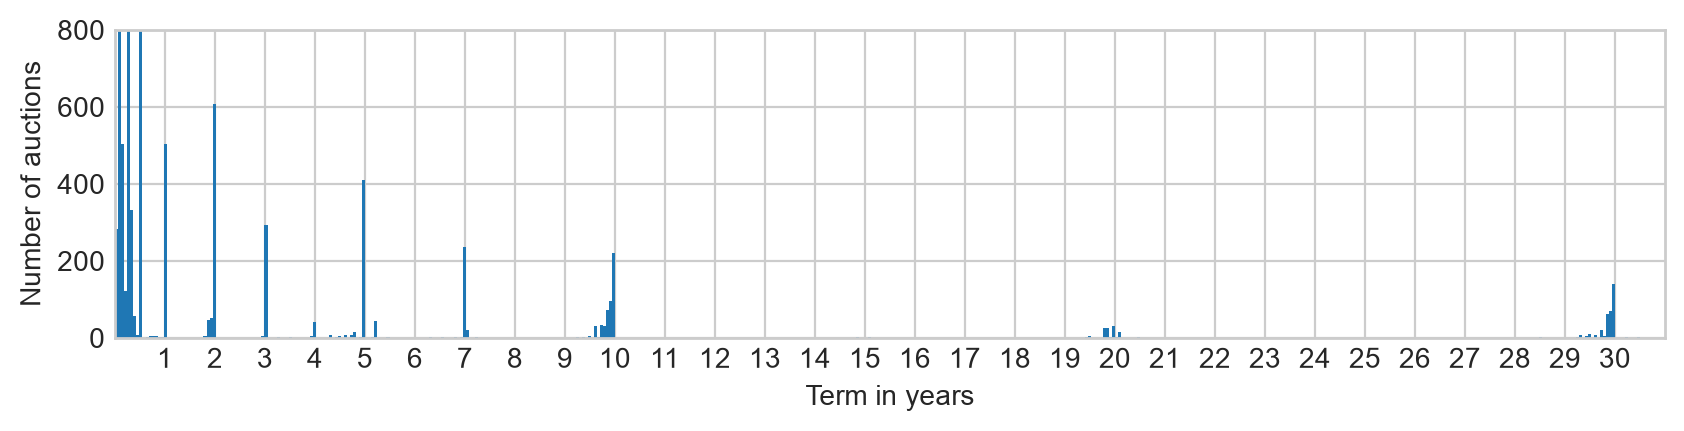

In [8]:
YEAR = 365.25
plt.figure(figsize=(10,2))
(df['term'].dt.days / YEAR).hist(bins=500)

plt.xlim(0, 31)
plt.ylim(0, 800)
plt.xticks(np.arange(1,31))
plt.ylabel("Number of auctions")
plt.xlabel("Term in years")

None

In [9]:
# Term brackets.

# The following defines the right boundaries of each term duration.
# We use the histogram above to pick the boundaries.
# Notice that the 10-year bond term spreads around 9.5 and 10 years, so in that case,
# we would pick the boundary at 9.0 year.

brackets = np.array([
  0.7 * YEAR,  # <= 6 months
  3.5 * YEAR,  # >= 6month,1,2,3 years
  9.0 * YEAR,  # 4,5,7 years
  100 * YEAR,  # 10,20,30 years
], dtype=np.int64)

brackets_labels = [
    "≤ 6 months",
    "6 month - 3 years",
    "4 - 7 years",
    "10 - 30 years",
]

# Debt over the years

In [ ]:
start_day = datetime(1979,1,1)
end_day = datetime(2060,1,1)
one_day = timedelta(days=1)

# We create the array of our 'x' containing all the days between 1980 and 2060.
days = np.arange(start_day, end_day, step=one_day).astype(datetime)

# We have a corresponding `debt` array corresponding to the debt on each day.
# (well, it's 4 arrays, one per term bracket).
debt = np.zeros((len(brackets), len(days)), dtype=np.int64)

# We are going to iterate through all the auction results, and add the `total_accepted` value for
# each day between the `issue_date` and `maturity_date`.

def num(value):
    # Sometimes there's missing data, we fill it with 0.
    return 0 if pd.isna(value) else value

for (i, row) in list(df.iterrows()):
    bracket_i = np.searchsorted(brackets, row['term'].days)

    for day in np.arange(row['issue_date'], row['maturity_date'], step=one_day).astype(datetime):
        day_i = (day - days[0]).days
        debt[bracket_i, day_i] += num(row['total_accepted'])

Debt today: $30.92 trillion


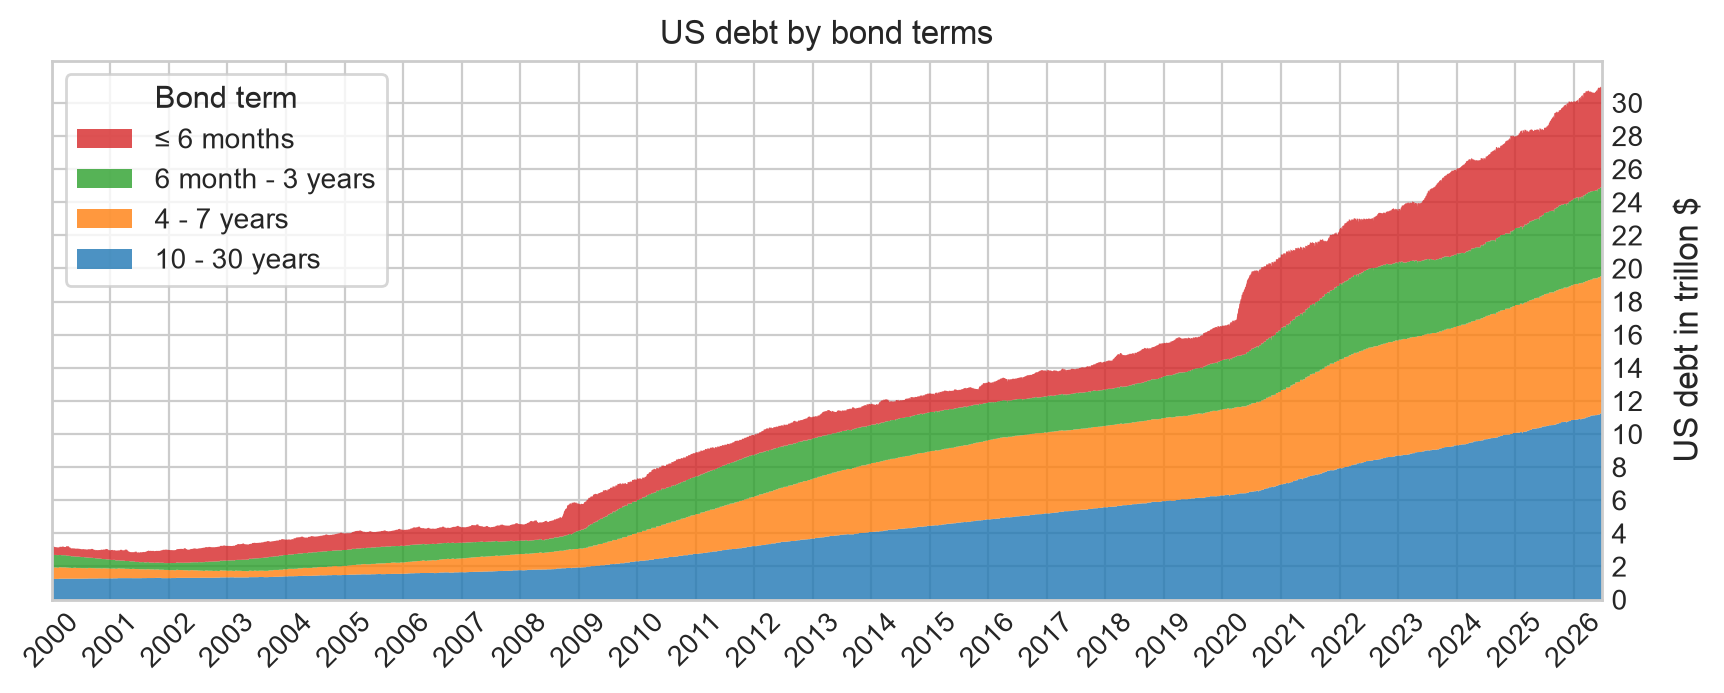

In [11]:
y = np.flip(debt, axis=0)
x = md.date2num(days)

plt.figure(figsize=(10,3.5))
plt.stackplot(x, y/1e12, alpha=0.8, labels=reversed(brackets_labels))

# x-axis labels
def show_years():
    xticks = []
    xticks_labels = []
    for year in np.arange(1980, 2060):
        xticks.append(datetime(year, 1, 1))
        xticks_labels.append(f"{year}")
    plt.xticks(md.date2num(xticks), xticks_labels)
    plt.xticks(rotation=45)
show_years()

# y-axis labels
plt.yticks(np.arange(0, 32, step=2))
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.ylabel("US debt in trillon $", labelpad=-595, fontsize=12)
plt.title("US debt by bond terms")

# Some awful tricks to reverse the order of the items in the legend.
def legend(title, **kwargs):
    l = plt.legend()
    plt.legend(handles=l.legend_handles[::-1], labels=[t.get_text() for t in l.texts][::-1],
               frameon=True, title=title, title_fontsize=11, **kwargs)
legend("Bond term")

plt.xlim(datetime(2000, 1, 1), today)

today_i = (today - days[0]).days
debt_as_of_today = debt[:,today_i].sum()
print(f"Debt today: ${debt_as_of_today / 1e12:.4} trillion")

## Are results correct?

Our auctions dataset only contains **marketable** securities (Bills, Notes, Bonds, TIPS, FRNs) that are sold at auction. By summing each security's accepted par from its `issue_date` to its `maturity_date`, what we compute is therefore **total marketable debt outstanding** — nothing more, nothing less.

The official Monthly Statement of the Public Debt (https://fiscaldata.treasury.gov/datasets/monthly-statement-public-debt/summary-of-treasury-securities-outstanding) confirms the match. As of 2026-05-31 (in \\$ trillions):

| Line | Official | Notes |
| --- | --- | --- |
| **Total Marketable Outstanding** | **\\$30.91T** | what we compute (\\~\\$30.94T, within \\~0.1%) |
| + Non-marketable held by the public | +\\$0.62T | Savings Bonds, SLGS, Domestic Series, GAS held by public — *never auctioned, so absent from our data* |
| − Marketable held intragovernmentally | −\\$0.02T | counted by us but not "public" |
| **= Debt Held by the Public** | **\\$31.52T** | |
| + Intragovernmental Holdings (GAS) | +\\$7.69T | special non-marketable securities issued to federal trust funds (Social Security, Medicare, federal retirement) — also never auctioned |
| **= Total Public Debt Outstanding** | **\\$39.21T** | |

**So our \\~\\$30.94 trillion is not "2% short due to missing data" — it is an accurate measure of total marketable debt. The remaining gap to the headline figures is purely definitional: non-marketable instruments (\\~\\$0.6T) make up the rest of debt held by the public, and the intragovernmental trust-fund debt (\\~\\$7.7T) makes up the rest of the total. Neither category is ever sold at auction, so neither can appear in this dataset.**

# Myth: The Great Debt Wall of America

I've been hearing the USA has a _debt wall_ coming up, a large amount of bonds maturing in a near future. Let's take a look how 2025 compares to other years.

We'll plot the amount of debt that would mature given different horizons.

We'll start with the 1 year horizon.

In [12]:
maturity_horizon = [
    timedelta(days=0.25 * YEAR),
    timedelta(days=0.50 * YEAR),
    timedelta(days=1.0 * YEAR),
    timedelta(days=2.0 * YEAR),
    timedelta(days=3.0 * YEAR),
]
maturity_labels = [
    "3 months",
    "6 months",
    "1 year",
    "2 years",
    "3 years"
]

maturity = np.zeros((len(maturity_horizon), len(brackets), len(days)), dtype=np.int64)

for (i, row) in list(df.iterrows()):
    bracket_i = np.searchsorted(brackets, row['term'].days)

    for (j, horizon) in enumerate(maturity_horizon):
        # This is the critical part. We consider the `maturity_date - horizon` without going before the issue_date.
        effective_start_day = max(row['issue_date'], row['maturity_date'] - horizon)
        end_day = row['maturity_date']

        for day in np.arange(effective_start_day, end_day, step=one_day).astype(datetime):
            day_i = (day - days[0]).days
            maturity[j, bracket_i, day_i] += num(row['total_accepted'])

US Debt maturing in the next 3 years: $16.87 trillion (54.6%)
US Debt maturing in the next 2 years: $14.09 trillion (45.6%)
US Debt maturing in the next 1 year: $10.23 trillion (33.1%)
US Debt maturing in the next 6 months: $8.118 trillion (26.3%)
US Debt maturing in the next 3 months: $5.684 trillion (18.4%)


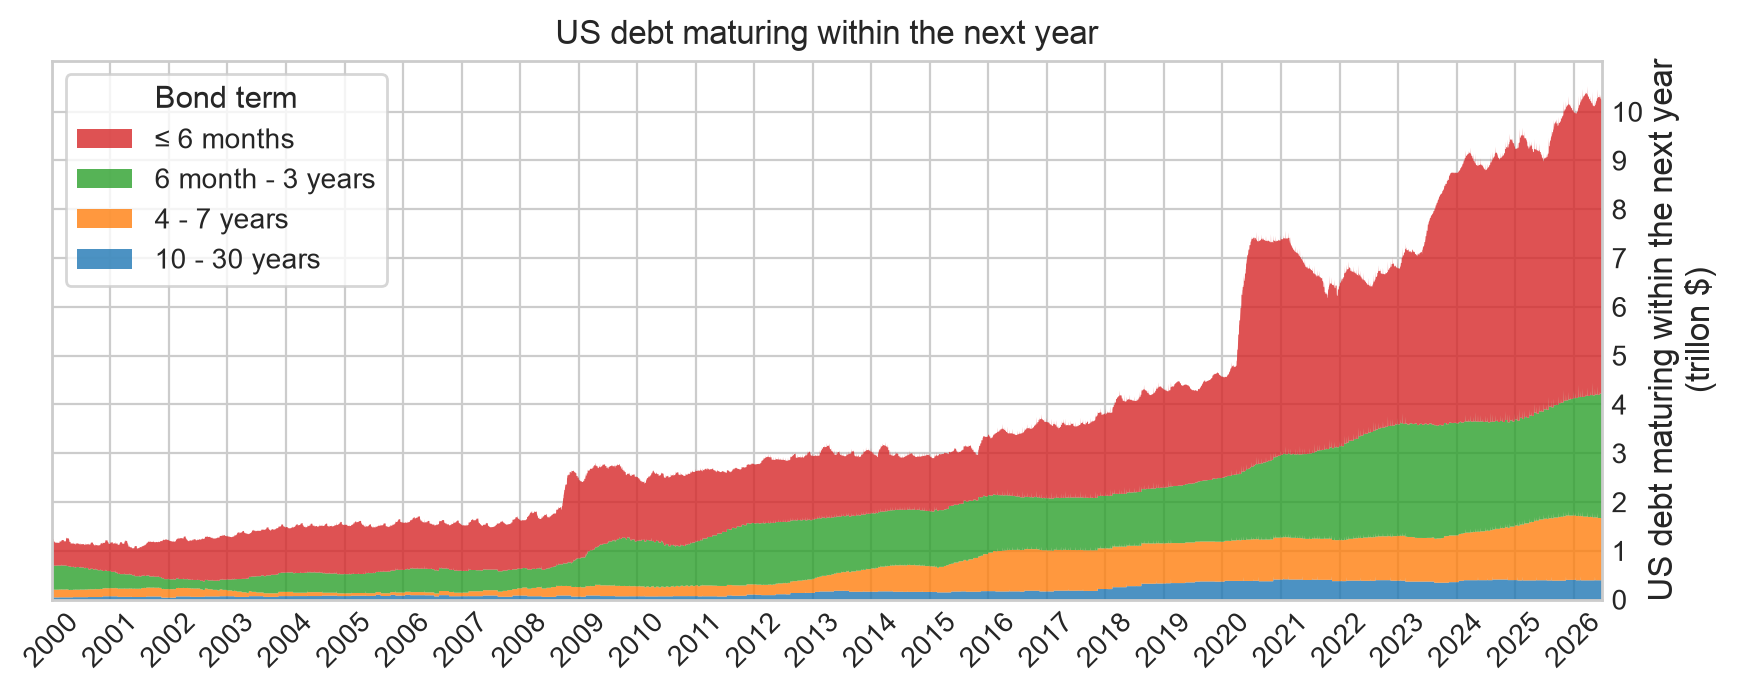

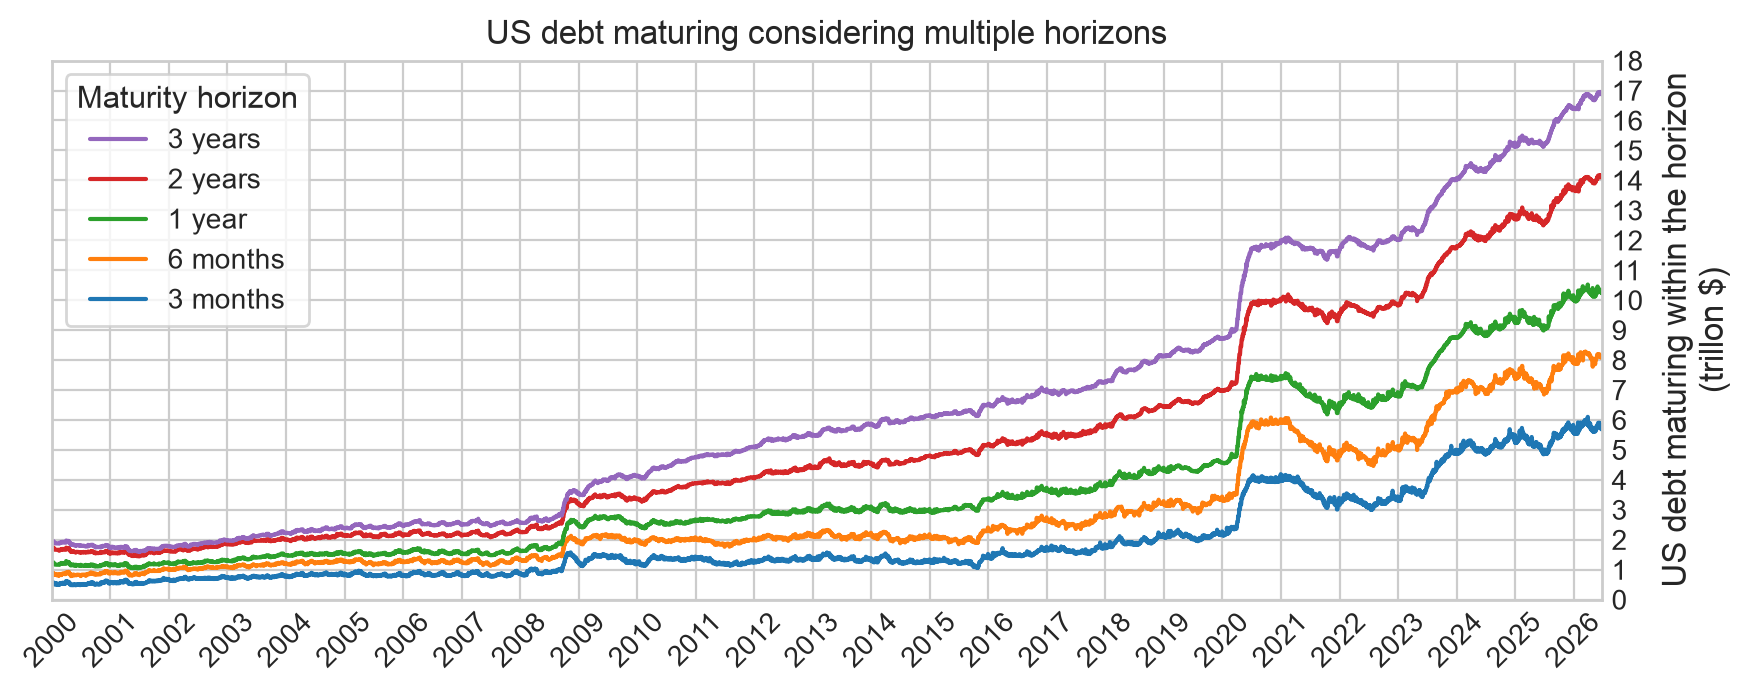

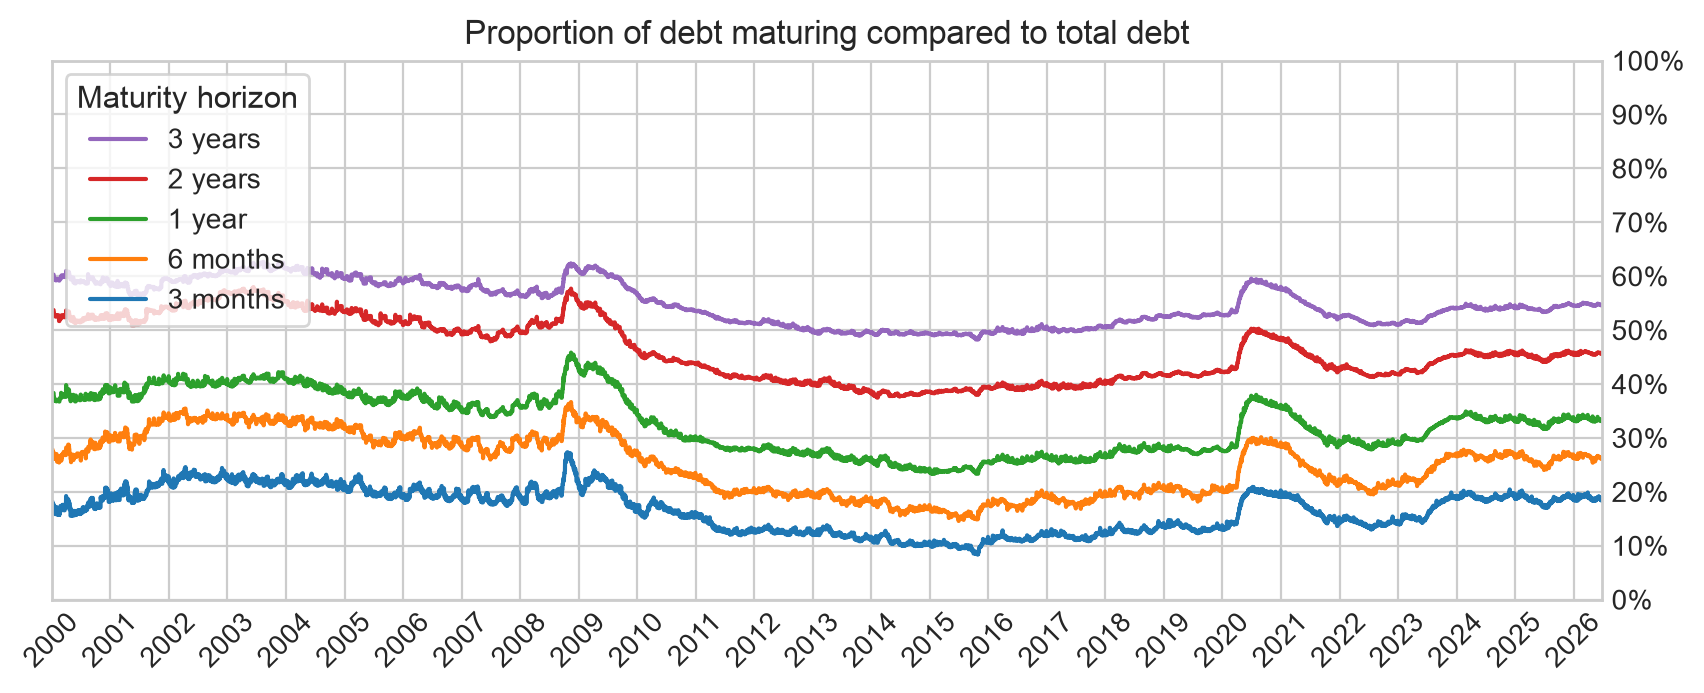

In [15]:
j = maturity_horizon.index(timedelta(YEAR))
y = np.flip(maturity[j], axis=0)
x = md.date2num(days)

plt.figure(figsize=(10,3.5))
plt.stackplot(x, y/1e12, alpha=0.8, labels=reversed(brackets_labels))

show_years()

# y-axis labels
plt.yticks(np.arange(0, 11, step=1))
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.ylabel("US debt maturing within the next year\n(trillon $)", labelpad=-600, fontsize=12)
plt.title("US debt maturing within the next year")

legend("Bond term")

plt.xlim(datetime(2000, 1, 1), today)


#### Graph 2

x = md.date2num(days)

plt.figure(figsize=(10,3.5))
for j in range(len(maturity_horizon)):
    y = maturity[j].sum(axis=0)
    plt.plot(x, y/1e12, label=maturity_labels[j])

show_years()

# y-axis labels
plt.yticks(np.arange(0, 19, step=1))
plt.ylim(0, 18)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.ylabel("US debt maturing within the horizon\n(trillon $)", labelpad=-605, fontsize=12)
plt.title("US debt maturing considering multiple horizons")

legend("Maturity horizon")

plt.xlim(datetime(2000, 1, 1), today)

#### Graph 3

plt.figure(figsize=(10,3.5))
for j in range(len(maturity_horizon)):
    y = maturity[j].sum(axis=0) / (debt.sum(axis=0)+1)
    plt.plot(x, 100.0 * y, label=maturity_labels[j])

show_years()

# y-axis labels
yticks = np.arange(0, 101, step=10)
plt.yticks(yticks, [f"{y}%" for y in yticks])
plt.ylim(0, 100)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
#plt.ylabel("", labelpad=-605, fontsize=12)
plt.title("Proportion of debt maturing compared to total debt")

legend("Maturity horizon", loc='upper left')

plt.xlim(datetime(2000, 1, 1), today)

for (j, label) in reversed(list(enumerate(maturity_labels))):
    maturing_as_of_today = maturity[j, :,today_i].sum()
    pct = 100.0 * maturing_as_of_today / debt_as_of_today
    print(f"US Debt maturing in the next {label}: ${maturing_as_of_today / 1e12:.4} trillion ({pct:.3}%)")

## Interpretation

Considering the 1-year-to-maturing debt of $9.23 trillion, we're not far from what it was in 2024.
It's been increasing and the trend is accelerating but I don't think we can really speak of a wall.

**When considering the trend in the past 25 years, the amount of debt to refinance is roughly constant over time. There's no wall of bonds coming to maturity, just a lot of debt.**

# Cost of Interests

In [ ]:
from pandas._libs.missing import NAType

interests = np.zeros((len(brackets), len(days)), dtype=np.int64)

skipped = []

for (i, row) in list(df.iterrows()):
    bracket_i = np.searchsorted(brackets, row['term'].days)

    rate = row['int_rate']
    if math.isnan(rate):
        # For Bills and Notes, there's no interest rate, this is the equivalent.
        if row['high_investment_rate'] is None:
            skipped.append(row)
            continue
        rate = float(row['high_investment_rate'])
        if math.isnan(rate):
            skipped.append(row)
            continue

    total_accepted = row['total_accepted']
    if isinstance(total_accepted, NAType):
        skipped.append(row)
        continue

    for day in np.arange(row['issue_date'], row['maturity_date'], step=one_day).astype(datetime):
        day_i = (day - days[0]).days
        interests[bracket_i, day_i] += total_accepted * (rate/100.0)

print(f"skipped auctions (missing data): {len(skipped)}")

skipped auctions (missing data): 156


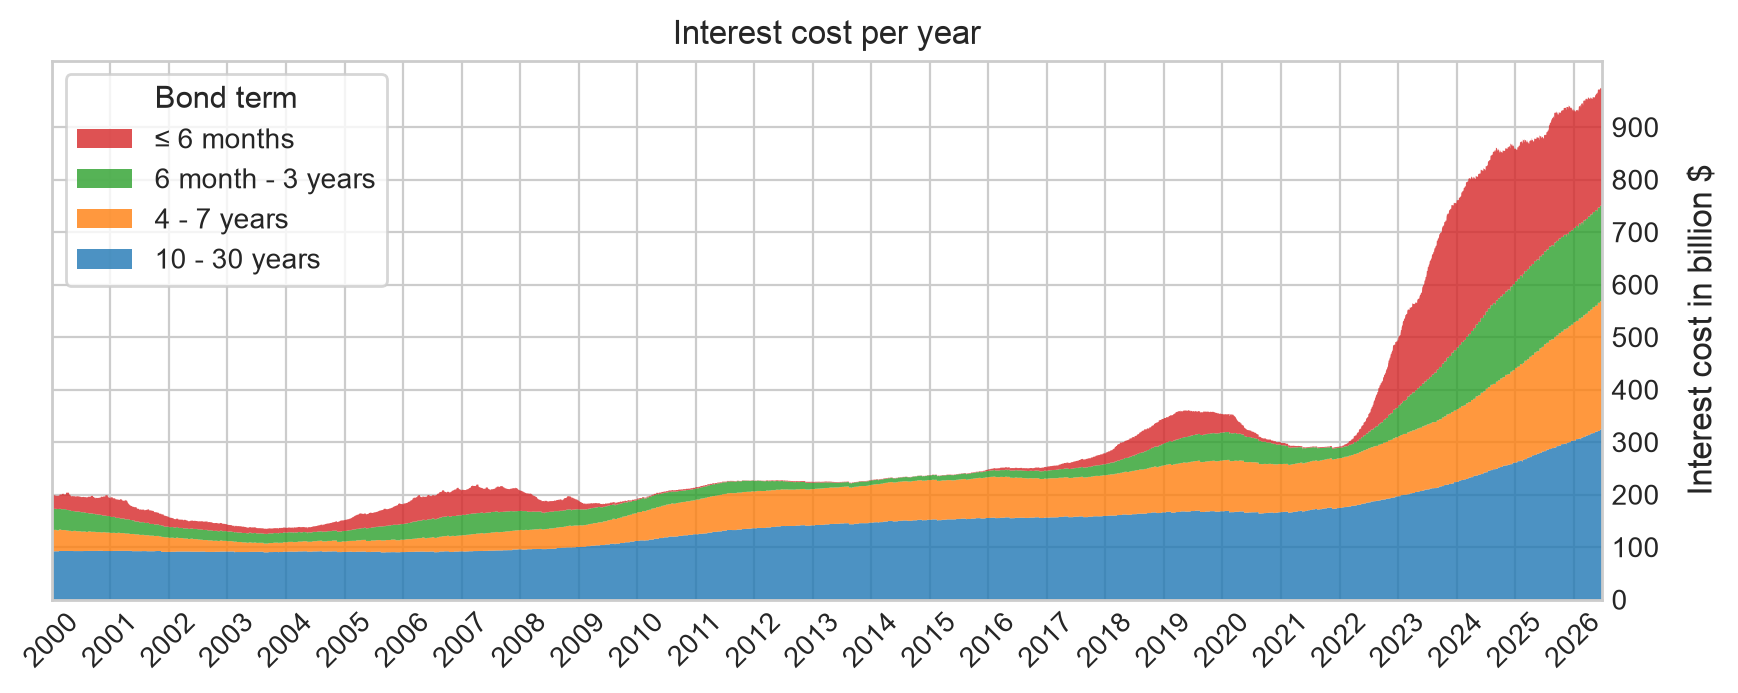

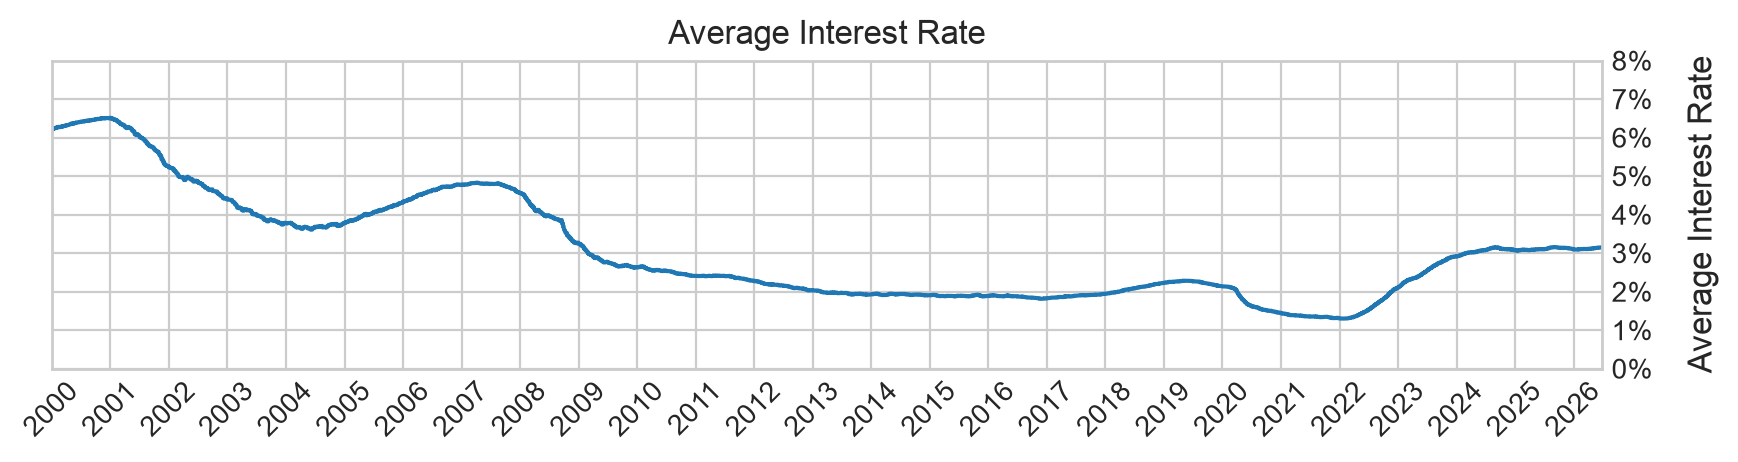

In [26]:
y = np.flip(interests, axis=0)
x = md.date2num(days)

plt.figure(figsize=(10,3.5))
plt.stackplot(x, y/1e9, alpha=0.8, labels=reversed(brackets_labels))

show_years()

# y-axis labels
plt.yticks(np.arange(0, 1000, step=100))
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.ylabel("Interest cost in billion $", labelpad=-600, fontsize=12)
plt.title("Interest cost per year")

legend("Bond term")

plt.xlim(datetime(2000, 1, 1), today)
None

### Graph 2

x = md.date2num(days)

plt.figure(figsize=(10,2))

plt.plot(x, 100.0 * interests.sum(axis=0)/(debt.sum(axis=0)+1))

show_years()

# y-axis labels
yticks = np.arange(0, 101, step=1)
plt.yticks(yticks, [f"{y}%" for y in yticks])
plt.ylim(0, 8)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.ylabel("Average Interest Rate", labelpad=-600, fontsize=12)
plt.title("Average Interest Rate")

plt.xlim(datetime(2000, 1, 1), today)
None

## Interpretation

The cost of the debt is skyrocketing, almost tripling in 3 years.